In [1]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import scipy.sparse as sp
import sys
import scipy

sys.path.append('../../1_figure_CL_proof_of_concept/code/')
import utils_00 as gf_utils
large_data_dir = gf_utils.large_data_dir

matplotlib.rcParams['pdf.fonttype'] = 42


In [2]:
adata = sc.read_h5ad(large_data_dir + 'MPN_WTA/homozygous_JAK2_mrvi_patient_as_nuisance.h5ad')

In [3]:
### simplify cell type names
adata.obs['cell_type'] = adata.obs['cell_type'].str.replace(' (non-HSPC)','', regex=False).str.replace(' (myeloid-primed)','', regex=False).str.replace(' 2','', regex=False).str.replace(' [tentative]','', regex=False).astype('category')

color_palette = {cell_type: color for cell_type, color in zip(adata.obs['cell_type'].cat.categories, adata.uns['cell_type_colors'])}

In [4]:
adata = adata[adata.obs['cell_type'] != 'Monocyte/Platelet doublet (non-HSPC)'].copy() ### remove these as doublets
adata.obs['cell_type'] = adata.obs['cell_type'].cat.remove_unused_categories()



In [5]:
# a function to compute entropy for a cell given the batch labels of cells in its neighborhood
def compute_entropy(labels, base=None):
    value, counts = np.unique(labels, return_counts=True)
    return scipy.stats.entropy(counts, base=base)

# a function to convert scanpy's nearest neighbor output to a more standard matrix 
def create_nn_mat(adata_temp, key):
    [row, col, val] = scipy.sparse.find(adata_temp.obsp[key])
    nn_mat = np.zeros(shape = (adata_temp.shape[0], sum(row == 0)))
    for item in range(adata_temp.shape[0]):
        nn_mat[item, :] = col[row == item]
    return nn_mat

# convert scanpy's nearest neighbor distance to a standard matrix
nn_mat = create_nn_mat(adata, key = 'neighbors_v_distances') ### these are z distances, incorrectly labeled as v

# compute entropy 
entropy = []
for r in range(nn_mat.shape[0]):
    labels = adata.obs['genotype'].iloc[nn_mat[r]]
    entropy_val = compute_entropy(labels, base = 2)
    entropy.append(entropy_val)

In [6]:
adata.obs['entropy'] = entropy
# Get entropy data by cell type
entropy_data = adata.obs[['cell_type', 'entropy']].copy()

# Sort cell types by median entropy, then by 75th percentile if median is the same
entropy_stats = entropy_data.groupby('cell_type')['entropy'].agg(['median', lambda x: np.percentile(x, 75)])
entropy_stats.columns = ['median', 'p75']
cell_type_order = entropy_stats.sort_values(['median', 'p75'], ascending=False).index

# Get colors for each cell type in the correct order
colors = [color_palette[ct] for ct in cell_type_order]

/tmp/ipykernel_782895/1245535296.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  entropy_stats = entropy_data.groupby('cell_type')['entropy'].agg(['median', lambda x: np.percentile(x, 75)])


/tmp/ipykernel_782895/274554834.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([entropy_data[entropy_data['cell_type'] == ct]['entropy'] for ct in cell_type_order],


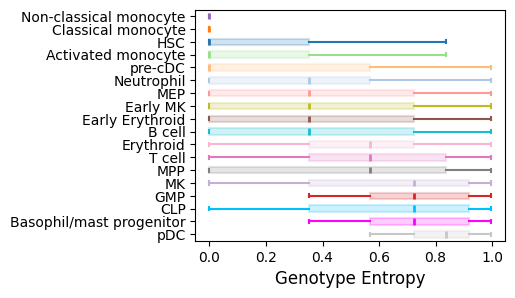

In [7]:
# Switch x and y by recreating the plot
fig, ax = plt.subplots(figsize=(4,3))

# Create horizontal box plot
bp = ax.boxplot([entropy_data[entropy_data['cell_type'] == ct]['entropy'] for ct in cell_type_order], 
                labels=cell_type_order, 
                patch_artist=True,
                showfliers=False,
                vert=False)  # Make horizontal

# Color the boxes
for patch, color in zip(bp['boxes'], colors):
    patch.set_edgecolor(color)
    patch.set_facecolor(color)
    patch.set_alpha(0.2)
    patch.set_linewidth(1.5)

# Color the whiskers and caps
for whisker, color in zip(bp['whiskers'], [c for c in colors for _ in range(2)]):
    whisker.set_color(color)
    whisker.set_linewidth(1.5)

for cap, color in zip(bp['caps'], [c for c in colors for _ in range(2)]):
    cap.set_color(color)
    cap.set_linewidth(1.5)

for median, color in zip(bp['medians'], colors):
    median.set_color(color)
    median.set_linewidth(2)

# Customize the plot
ax.set_xlabel('Genotype Entropy', fontsize=12)
plt.savefig('../plots/z_space_genotype_entropy.pdf')
